In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [5]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [6]:
df = pd.read_csv('sp500sub.csv', index_col = 'Date', parse_dates=True)

In [7]:
goog = df[df['Name']=='GOOG'][['Close']].copy()

In [9]:
def log_ret(price):
    log_price = np.log(price)
    return log_price.diff()

In [10]:
goog['LogRet'] =  log_ret(goog['Close'])

In [11]:
goog.head()

,Close,LogRet
Date,,
2010-01-04,312.204773,NaN
2010-01-05,310.829926,-0.004413
2010-01-06,302.994293,-0.025532
2010-01-07,295.940735,-0.023555
2010-01-08,299.885956,0.013243


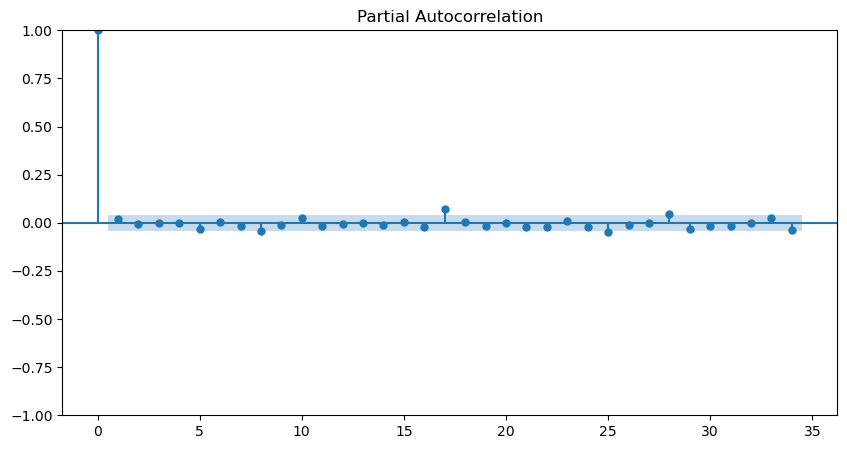

In [12]:
fig, ax = plt.subplots(figsize = (10,5))
plot_pacf(goog['LogRet'].dropna(), ax = ax);

In [19]:
''' pacf is done to choose the order p for the autoregressive AR model.
no auto correlation exists for lags greater than 0.
some points at say 17 is outside the confidence interval but that could happen by chance as well 5% of the times. also its not significantly outside 
the confidence interval.

HENCE CHOOSING P=0
'''

' pacf is done to choose the order p for the autoregressive AR model.\nno auto correlation exists for lags greater than 0.\nsome points at say 17 is outside the confidence interval but that could happen by chance as well 5% of the times. also its not significantly outside \nthe confidence interval.\n\nHENCE CHOOSING P=0\n'

#### just checking if log returns is stationary before pacf is applied since ARMA model should be performed on stationary trends
##### this should have been performed before taking the pacf/acf

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
adfuller(goog['LogRet'].dropna())

(np.float64(-46.66748022773677),
 0.0,
 0,
 2261,
 {'1%': np.float64(-3.4332455062745577),
  '5%': np.float64(-2.862819159865148),
  '10%': np.float64(-2.567450956377989)},
 np.float64(-12328.09150223395))

<Axes: xlabel='Date'>

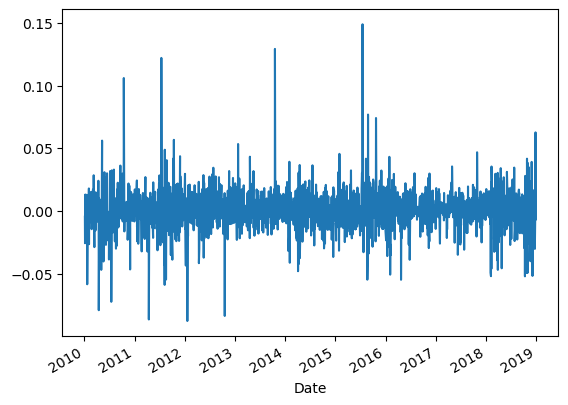

In [24]:
goog['LogRet'].plot()

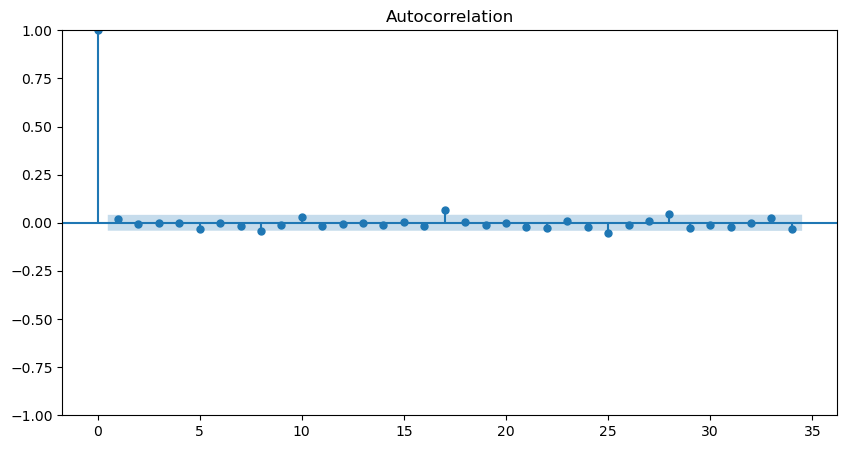

In [15]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(goog['LogRet'].dropna(), ax = ax);

In [20]:
''' same reason as explained in the pacf. HENCE CHOOSING Q = 0'''

' same reason as explained in the pacf. HENCE CHOOSING Q = 0'

# CONCLUSION - if we were to choose arima order p,d,q manualy using pacf and acf plots, we would be choosing (0,1,0)
# meaning random walk

In [21]:
aapl = df[df['Name']=='AAPL'][['Close']].copy()

aapl['LogRet'] =  log_ret(aapl['Close'])

<Axes: xlabel='Date'>

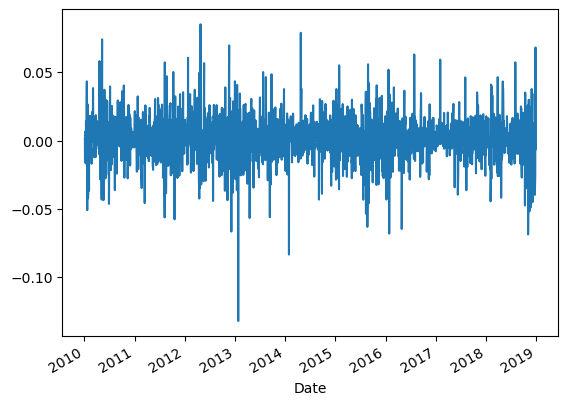

In [22]:
aapl['LogRet'].plot()

In [26]:
adfuller(aapl['LogRet'].dropna())

(np.float64(-13.123024851095424),
 np.float64(1.5491679316405788e-24),
 12,
 2249,
 {'1%': np.float64(-3.4332609735287223),
  '5%': np.float64(-2.862825989564547),
  '10%': np.float64(-2.5674545927076724)},
 np.float64(-12098.80822549191))

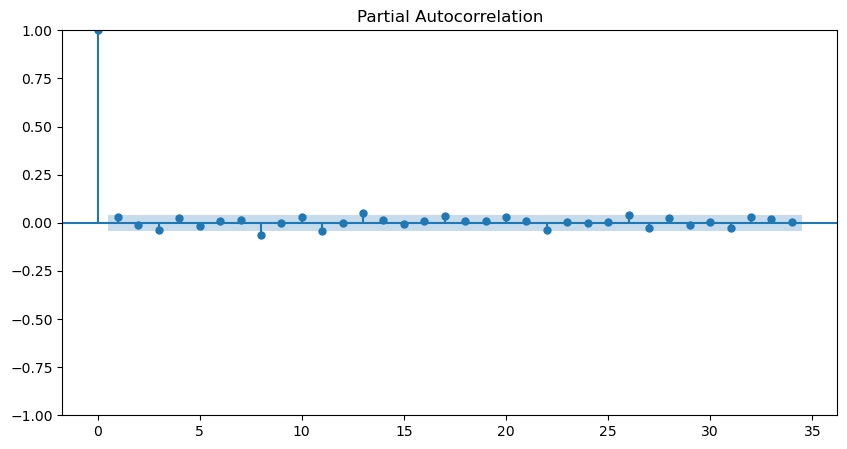

In [27]:
fig, ax = plt.subplots(figsize = (10,5))
plot_pacf(aapl['LogRet'].dropna(), ax = ax);

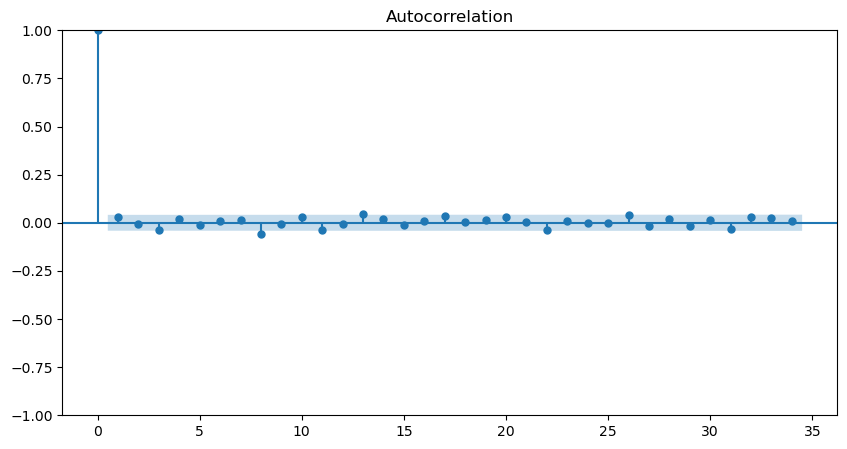

In [28]:

fig, ax = plt.subplots(figsize = (10,5))
plot_acf(aapl['LogRet'].dropna(), ax = ax);